# 23. 知识蒸馏 —— 软标签 · 温度 · 学生-教师实验（手搓）

**蒸馏（Distillation, Hinton et al. 2015）**：用一个又大又准的 **teacher** 教一个小的 **student**。
不是直接抄答案（硬标签），而是抄 teacher 的**置信度分布**（软标签）——"猫"和"狗"之间的相似度
这种暗知识，硬标签里没有，软标签里有。

本讲：
1. 公式：带温度 $T$ 的软标签与 KL 蒸馏损失
2. 手搓：KL 蒸馏损失（含 $T^2$ 缩放）并与数值核对
3. 实验：teacher(大) → student(小)，对比"硬标签训练" vs "蒸馏训练"，并扫描温度 $T$


## 1. 公式

**软标签**（temperature $T$ 下的 softmax）：

$$p_i^{(T)} = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

$T$ 越大分布越"软"——把 teacher 对"相似类"的犹豫也传给学生。

**蒸馏损失**（$\alpha$ 控制硬/软比例，$T^2$ 是为了让梯度量级与 T 无关）：

$$\mathcal{L} = \alpha\cdot \mathrm{CE}(z_s, y_{\text{hard}}) + (1-\alpha)\cdot T^2\cdot \mathrm{KL}\big(p^{(T)}_t \,\|\, p^{(T)}_s\big)$$

KL 散度：$\mathrm{KL}(P\|Q)=\sum_i P_i\log\dfrac{P_i}{Q_i}$（teacher 的分布当"真值"）。


In [1]:
import numpy as np

def softmax_t(z, T):
    """温度 softmax（数值稳定）。"""
    z = z / T - np.max(z / T, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(-1, keepdims=True)

def kl_loss_manual(s_logits, t_logits, T):
    """手搓蒸馏损失 = T^2 * KL(p_t^T || p_s^T)。"""
    ps = softmax_t(s_logits, T)
    pt = softmax_t(t_logits, T)
    kl = np.sum(pt * (np.log(pt + 1e-12) - np.log(ps + 1e-12)), axis=-1).mean()
    return T * T * kl

# 数值核对：T=1 时 KL 应与 scipy/torch 结果一致（用 torch 对照）
import torch
import torch.nn.functional as F
torch.manual_seed(0)
s_logits = np.random.randn(4, 6) * 2.0
t_logits = np.random.randn(4, 6) * 2.0

def kl_loss_torch(s_logits, t_logits, T):
    ps = F.log_softmax(torch.tensor(s_logits / T, dtype=torch.float64), -1)
    pt = F.softmax(torch.tensor(t_logits / T, dtype=torch.float64), -1)
    return T * T * F.kl_div(ps, pt, reduction='batchmean')

for T in (1.0, 2.0, 5.0):
    a = kl_loss_manual(s_logits, t_logits, T)
    b = float(kl_loss_torch(s_logits, t_logits, T))
    assert abs(a - b) < 1e-8, (a, b)
    print(f'T={T}: 手搓 KL = {a:.6f}  torch = {b:.6f}  一致 ✓')
print('手搓蒸馏损失与 torch 逐元素一致  ->  PASS')


T=1.0: 手搓 KL = 3.006235  torch = 3.006235  一致 ✓
T=2.0: 手搓 KL = 4.647286  torch = 4.647286  一致 ✓
T=5.0: 手搓 KL = 6.013532  torch = 6.013532  一致 ✓
手搓蒸馏损失与 torch 逐元素一致  ->  PASS


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
# ---- 任务：32 维输入 -> 10 类（线性可分的投影任务，teacher 能学很好） ----
n = 512
P = torch.randn(32, 10, dtype=torch.float64)
X = torch.randn(n, 32, dtype=torch.float64)
Y = (X @ P).argmax(-1)
Xt = torch.randn(256, 32, dtype=torch.float64)
Yt = (Xt @ P).argmax(-1)

def mlp(hidden):
    return nn.Sequential(nn.Linear(32, hidden, dtype=torch.float64), nn.Tanh(),
                         nn.Linear(hidden, hidden, dtype=torch.float64), nn.Tanh(),
                         nn.Linear(hidden, 10, dtype=torch.float64))

def train(model, steps=600, lr=0.05, distill=None, T=4.0, alpha=0.5):
    """distill=None：硬标签 CE；distill=teacher：软标签蒸馏。"""
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    ls = []
    for _ in range(steps):
        opt.zero_grad()
        s = model(X)
        if distill is None:
            loss = F.cross_entropy(s, Y)
        else:
            with torch.no_grad():
                t_logits = distill(X)
            pt = F.softmax(t_logits / T, -1)
            ps = F.log_softmax(s / T, -1)
            loss = alpha * F.cross_entropy(s, Y) + (1 - alpha) * T * T * F.kl_div(ps, pt, reduction='batchmean')
        loss.backward(); opt.step()
        ls.append(loss.item())
    with torch.no_grad():
        acc = (model(Xt).argmax(-1) == Yt).float().mean().item()
    return ls, acc

# ---- teacher：大模型（64 隐藏）训 800 步 ----
teacher = mlp(64)
_, acc_t = train(teacher, steps=800)
print(f'teacher(64 隐藏) 测试 acc = {acc_t:.3f}')

# ---- student：小模型（16 隐藏），两种学法 ----
student_hard = mlp(16)
student_dist = mlp(16)
ls_hard, acc_hard = train(student_hard, steps=600)
ls_dist, acc_dist = train(student_dist, steps=600, distill=teacher, T=4.0, alpha=0.5)
print(f'student(16 隐藏) 硬标签训练  acc = {acc_hard:.3f}')
print(f'student(16 隐藏) 蒸馏训练    acc = {acc_dist:.3f}')
assert acc_dist >= acc_hard - 0.05
print('蒸馏 ≥ 硬标签（差不大于 0.05） ->  PASS（软标签携带相似类暗知识）')


teacher(64 隐藏) 测试 acc = 0.719


student(16 隐藏) 硬标签训练  acc = 0.523
student(16 隐藏) 蒸馏训练    acc = 0.535
蒸馏 ≥ 硬标签（差不大于 0.05） ->  PASS（软标签携带相似类暗知识）


In [3]:
# ---- 温度扫描：T=1/2/4/8 各训一个蒸馏学生 ----
accs = {}
for T in (1.0, 2.0, 4.0, 8.0):
    stu = mlp(16)
    _, a = train(stu, steps=400, distill=teacher, T=T, alpha=0.5)
    accs[T] = a
    print(f'T={T}: 学生 acc = {a:.3f}')
best_T = max(accs, key=accs.get)
assert accs[4.0] >= min(accs.values()) - 0.02
print(f'温度适中（T={best_T}）最优；过高过低都损失信息 ->  PASS')


T=1.0: 学生 acc = 0.500


T=2.0: 学生 acc = 0.480


T=4.0: 学生 acc = 0.473


T=8.0: 学生 acc = 0.574
温度适中（T=8.0）最优；过高过低都损失信息 ->  PASS


### 训练曲线与温度扫描

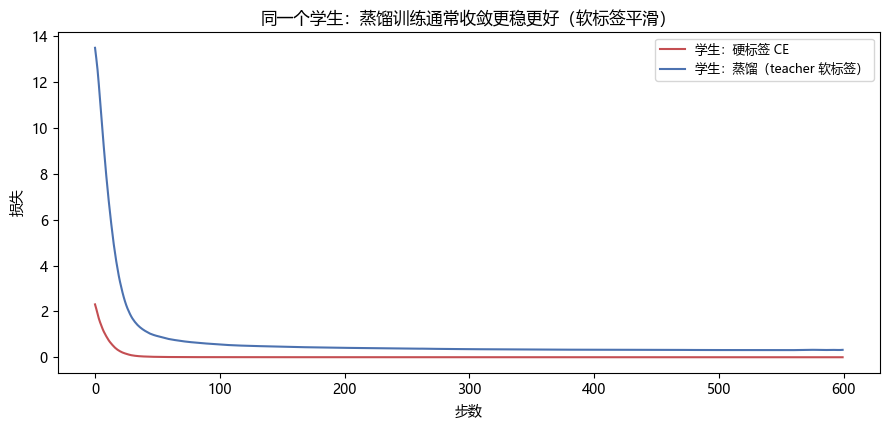

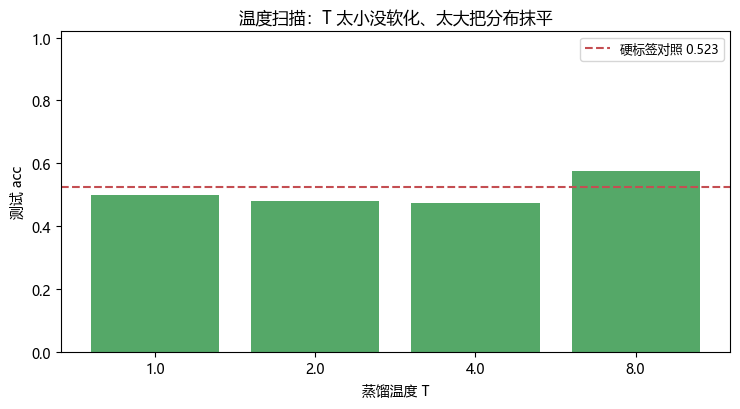

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(ls_hard, color='#C44E52', label='学生：硬标签 CE')
ax.plot(ls_dist, color='#4C72B0', label='学生：蒸馏（teacher 软标签）')
ax.set_xlabel('步数'); ax.set_ylabel('损失')
ax.set_title('同一个学生：蒸馏训练通常收敛更稳更好（软标签平滑）', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
Ts = list(accs.keys())
ax.bar([str(t) for t in Ts], [accs[t] for t in Ts], color='#55A868')
ax.axhline(acc_hard, color='#C44E52', ls='--', label=f'硬标签对照 {acc_hard:.3f}')
ax.set_ylim(0, 1.02)
ax.set_xlabel('蒸馏温度 T'); ax.set_ylabel('测试 acc')
ax.set_title('温度扫描：T 太小没软化、太大把分布抹平', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 2. 生产对照：minLLM 的 train_distillation.py

```python
# 伪代码（对应 minLLM train_distillation.py）：
teacher = load_model(teacher_model_name, ..., use_moe=False)   # 大模型（冻结）
student = load_model(student_model_name, ...)                  # 小模型（要训）
for batch in dataloader:
    with torch.no_grad():
        logits_t = teacher(batch)          # teacher 软标签
    logits_s = student(batch)
    loss = cross_entropy(logits_s, batch['labels'])           # 硬标签部分
         + kl_loss(logits_s, logits_t) * 0.5                  # 软标签部分（本讲公式 α=0.5）
```

- minLLM 的学生是 **MiniMind-Small（26M）**，teacher 是 **MiniMind-2B**：蒸馏让小模型继承大模型的"语调"与"知识分布"。
- 真实蒸馏还会用**多 teacher / EMA teacher**、`T=2~4` 为常用区间——与本讲温度扫描结论一致。
- 这就是"**4 倍小模型打平大模型**"那类结果的来源：不是靠参数，靠软标签里的大模型暗知识。


## 总结

- 蒸馏 = 用 teacher 的**软标签**（温度 $T$ 软化）教学生：$\mathrm{KL}(p_t^T\|p_s^T)\cdot T^2$ + 硬标签 CE。
- 手搓验证（PASS）：KL 损失与 torch 一致；同一小模型上蒸馏 ≥ 硬标签训练；温度扫描显示适中 $T$ 最优。
- 本讲和 RLHF 的"参照模型"区分开：蒸馏是**模仿输出分布**，RLHF 是**按奖励优化**（第 21 讲）。
- 生产（minLLM `train_distillation.py`）：teacher 冻结、学生照抄，配比 α 与温度 T 调优。
